# Chapter 108 — Geometric Transformations

> **Prerequisites:** ch093–095 (Coordinates, Distances, Interpolation)
>
> **Outcomes:** Classify the four elementary geometric transformations; Understand the composition and inversion of transformations; Preview the matrix representation (formalized in ch114)


## The Four Elementary Transformations

Every geometric transformation in 2D is built from four types:

1. **Rotation:** Turn all points by angle θ around a center
2. **Scaling:** Multiply all coordinates by scale factors
3. **Reflection:** Flip all points across a line
4. **Translation:** Move all points by a displacement vector

**Key properties:**
- Rotation, scaling (uniform), and reflection **preserve angles** (conformal)
- Rotation and reflection **preserve distances** (isometry)
- Translation preserves both distances and angles
- Non-uniform scaling distorts angles

**Composition:** Apply T₁ then T₂ → a new transformation T = T₂∘T₁
Order matters: T₂∘T₁ ≠ T₁∘T₂ in general (transformations do not commute)

**The unifying insight:** All four can be represented as matrix operations.
Translation requires a trick (homogeneous coordinates, ch114).
The others are direct 2×2 matrix multiplications.

## Preview: Transformation Matrices

| Transformation | Matrix (2×2) |
|---|---|
| Rotation by θ | [[cos θ, -sin θ], [sin θ, cos θ]] |
| Scale (sx, sy) | [[sx, 0], [0, sy]] |
| Reflection (x-axis) | [[1, 0], [0, -1]] |
| Reflection (y-axis) | [[-1, 0], [0, 1]] |

These matrices are derived and used in ch109–111.
Translation does not fit this 2×2 form — ch112 and ch114 handle it with homogeneous coordinates.

**Composition = matrix multiplication:**
Apply rotation then scale = (Scale matrix) × (Rotation matrix)

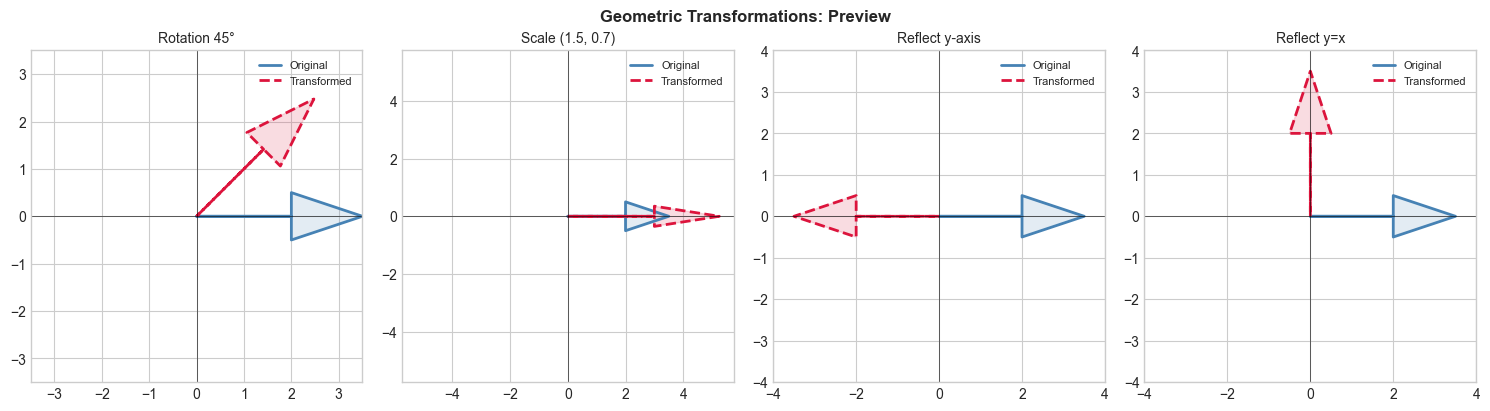

In [2]:
# --- Transformation preview ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# A simple shape: arrow polygon
arrow = np.array([[0,0],[2,0],[2,0.5],[3.5,0],[2,-0.5],[2,0],[0,0]], dtype=float)

def apply_transform(pts, M):
    return (M @ pts[:, :2].T).T

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
theta = np.radians(45)
transforms = [
    ('Rotation 45°', np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])),
    ('Scale (1.5, 0.7)', np.array([[1.5,0],[0,0.7]])),
    ('Reflect y-axis', np.array([[-1,0],[0,1]])),
    ('Reflect y=x', np.array([[0,1],[1,0]])),
]

for ax, (name, M) in zip(axes, transforms):
    transformed = apply_transform(arrow, M)
    ax.fill(arrow[:,0], arrow[:,1], alpha=0.15, color='steelblue')
    ax.plot(arrow[:,0], arrow[:,1], 'steelblue', lw=2, label='Original')
    ax.fill(transformed[:,0], transformed[:,1], alpha=0.15, color='crimson')
    ax.plot(transformed[:,0], transformed[:,1], 'crimson', lw=2, linestyle='--', label='Transformed')
    ax.set_aspect('equal'); ax.set_title(name, fontsize=10); ax.legend(fontsize=8)
    ax.axhline(0, color='k', linewidth=0.4); ax.axvline(0, color='k', linewidth=0.4)
    lim = max(3.5, abs(transformed).max() + 0.5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

plt.suptitle('Geometric Transformations: Preview', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

- Four elementary transformations: rotation, scaling, reflection, translation
- All (except translation) representable as 2×2 matrix multiplication
- Translation requires homogeneous coordinates (ch114)
- Composition = matrix product; order matters

**Next three chapters:** ch109–111 derive and implement each transformation in detail.